##### The Algerian Forest Fires Dataset is a popular machine learning dataset used for classification (Fire vs Not Fire) and sometimes regression tasks involving fire risk prediction.

> Dataset Overview
- 1.Instances: 244
- 2.Regions: Two regions of Algeria
   - Bejaia (122 records)
   - Sidi-Bel-Abbes (122 records)
- 3.Time Period: June 2012 – September 2012
- 4.Target Variable: Classes
   -  Fire (138 instances)
   - Not Fire (106 instances)

### Algerian Forest Fires Dataset - Feature Full Forms

#### 🔥 Weather Features

| Abbreviation | Full Form           | Meaning                              |
|--------------|--------------------|--------------------------------------|
| RH           | Relative Humidity  | Percentage of moisture in the air    |
| Ws           | Wind Speed         | Speed of wind (km/h)                 |
| Rain         | Rainfall           | Amount of precipitation (mm)         |
| Temp         | Temperature        | Air temperature (°C)                 |

---

#### 🌲 Fire Weather Index (FWI) Components

| Abbreviation | Full Form                     | Meaning |
|--------------|------------------------------|--------|
| FFMC         | Fine Fuel Moisture Code      | Moisture of surface litter (leaves, twigs); affects ignition |
| DMC          | Duff Moisture Code           | Moisture in loosely compacted organic layers |
| DC           | Drought Code                 | Moisture in deep, compact organic layers (long-term dryness) |
| ISI          | Initial Spread Index         | Rate of fire spread immediately after ignition |
| BUI          | Buildup Index                | Total fuel available for combustion |
| FWI          | Fire Weather Index           | Overall fire intensity indicator |

---

#### 🧠 Quick Interpretation

- High **FFMC** → Easy ignition  
- High **DMC/DC** → Dry forest → Sustained burning  
- High **ISI** → Fast fire spread  
- High **BUI** → More fuel available  
- High **FWI** → High fire danger  

---

#### ⚠️ Important Insight

FWI system is hierarchical:

```
FFMC, DMC, DC  →  ISI + BUI  →  FWI
```

- FWI is derived → not an independent feature  
- Be careful of multicollinearity in regression models  

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
df=pd.read_csv("Algerian_forest_fires_dataset.csv")
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


##### DATA CLEANING

In [4]:
## missing values
df.isnull().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
dtype: int64

In [5]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


- The datset is converted onto two sets based on Region from 122th index, we can make a new column based on the Region
- 1. Bejaia Region Dataset
- 2. Sidi-Bel Abbes Region Dataset
- Add new column with region

In [6]:
df.loc[:122,"Region"]=0
df.loc[122:,"Region"]=1

In [7]:
df[["Region"]]=df[["Region"]].astype(int)

In [8]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [9]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
167,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN,1


In [10]:
## remove the null values
df=df.dropna().reset_index(drop=True)

In [11]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [12]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1


In [13]:
df=df.drop(122).reset_index(drop=True)

In [14]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,1,6,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1


In [15]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

In [16]:
## fix spaces in column name
df.columns=df.columns.str.strip()
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    object
 1   month        243 non-null    object
 2   year         243 non-null    object
 3   Temperature  243 non-null    object
 4   RH           243 non-null    object
 5   Ws           243 non-null    object
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 28.6+ KB


#### ***Changing the required columns as integers and floats***

In [18]:
df.head(3)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0


In [19]:
df[['month','day','year','Temperature','RH','Ws']]=df[['month','day','year','Temperature','RH','Ws']].astype(int)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    int64 
 1   month        243 non-null    int64 
 2   year         243 non-null    int64 
 3   Temperature  243 non-null    int64 
 4   RH           243 non-null    int64 
 5   Ws           243 non-null    int64 
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int64 
dtypes: int64(7), object(8)
memory usage: 28.6+ KB


In [21]:
objects=[features for features in df.columns if df[features].dtypes=='O']

In [22]:
for i in objects:
    if i != "Classes":
        df[i] = df[i].astype(float)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.6+ KB


In [24]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [25]:
## save the clean data set
df.to_csv("Algerian_forest_fires_dataset_cleaned.csv",index=False)

#### ***Exploratory Data Analysis***

In [26]:
df_copy = df

In [27]:
df_copy.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [28]:
df_copy=df_copy.drop(['day','month','year'],axis=1)

In [29]:
df_copy.head(2)

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0


In [30]:
## catergory in Classes
df_copy['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [31]:
## Encoding of the categories in classes
df_copy['Classes']=np.where(df_copy['Classes'].str.contains('not fire'),0,1)

In [32]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [33]:
df_copy['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

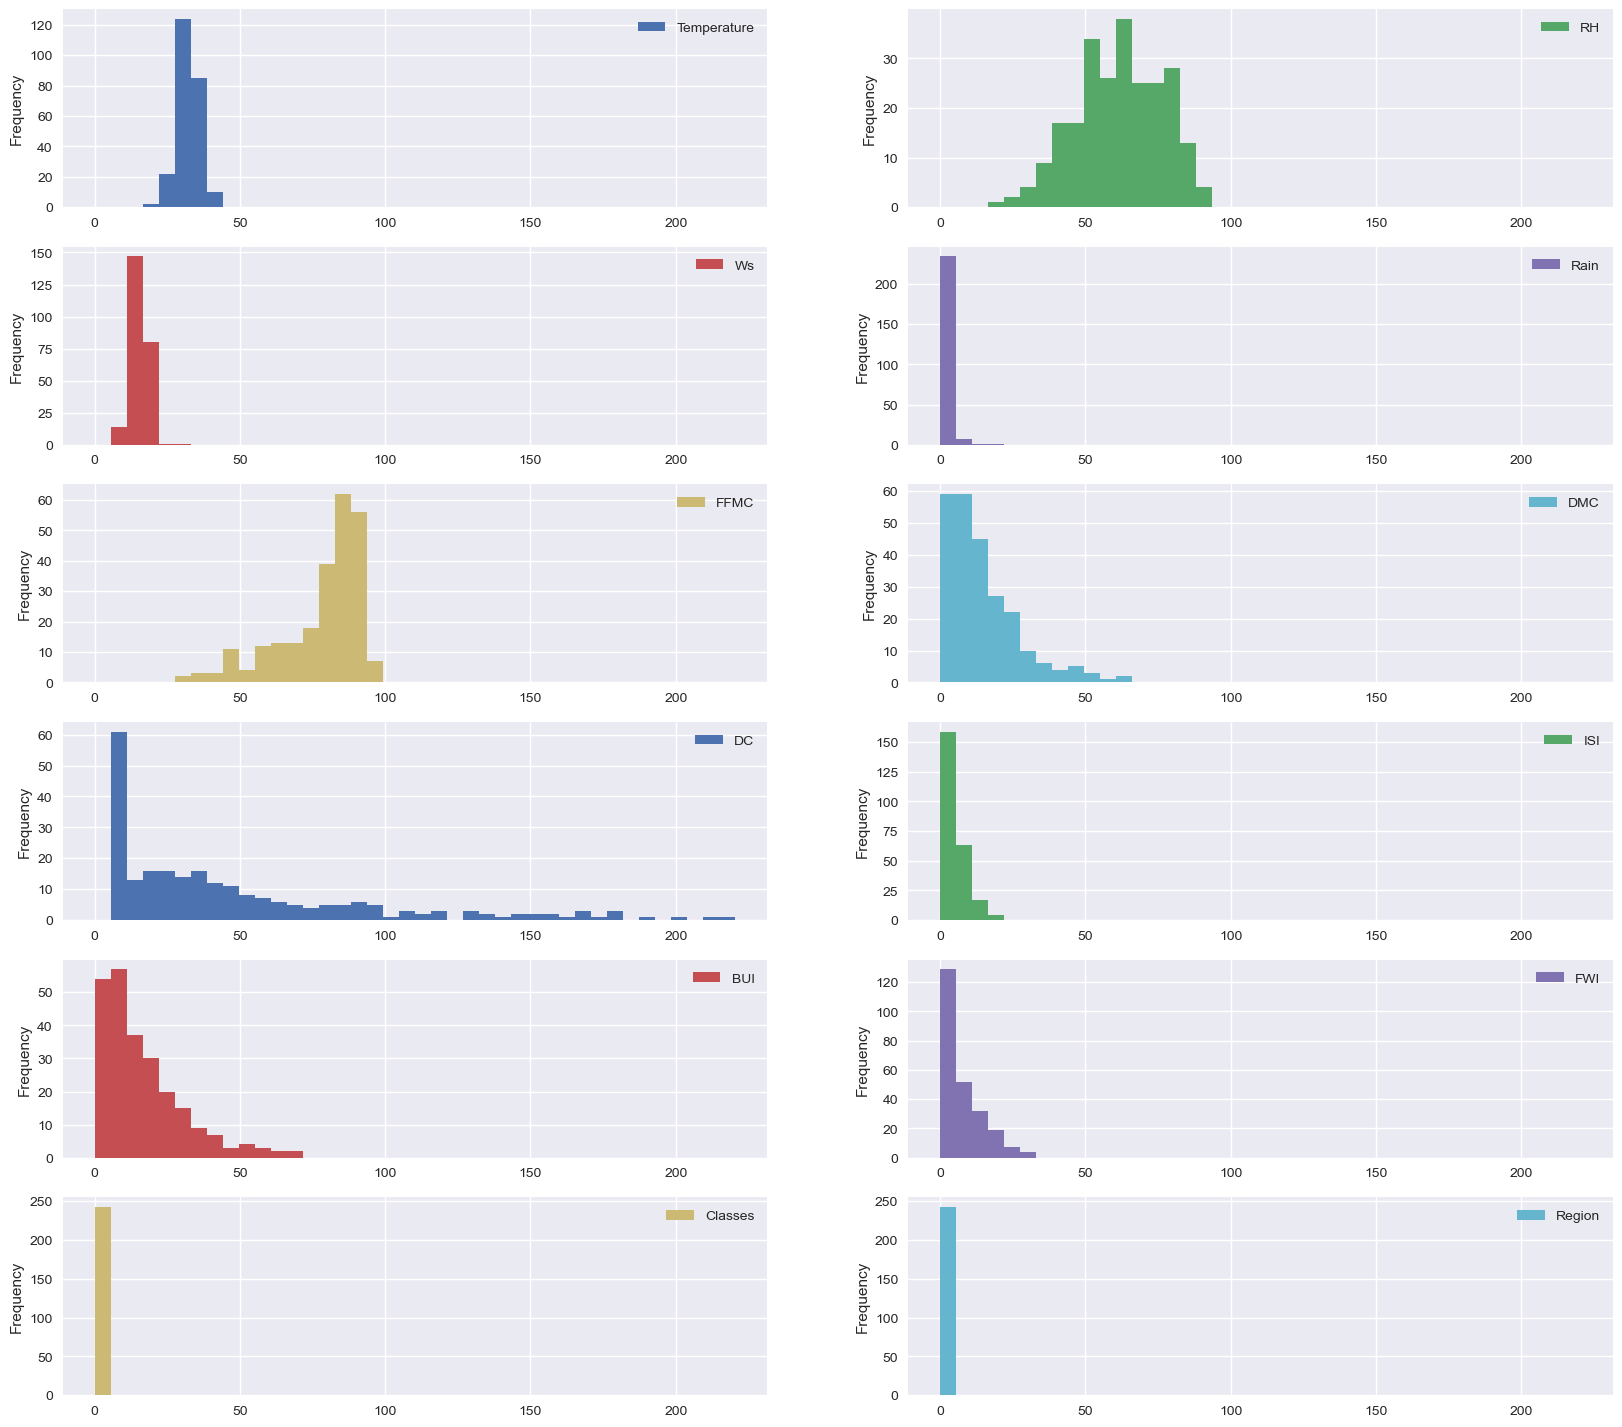

In [34]:
## hist plot for all
plt.style.use('seaborn-v0_8')
import math
cols = df_copy.shape[1]
rows=math.ceil(cols/2)
df_copy.plot(kind='hist',bins=40,subplots=True,sharex=False,layout=(rows,2),figsize=(20,rows*3))
plt.show()

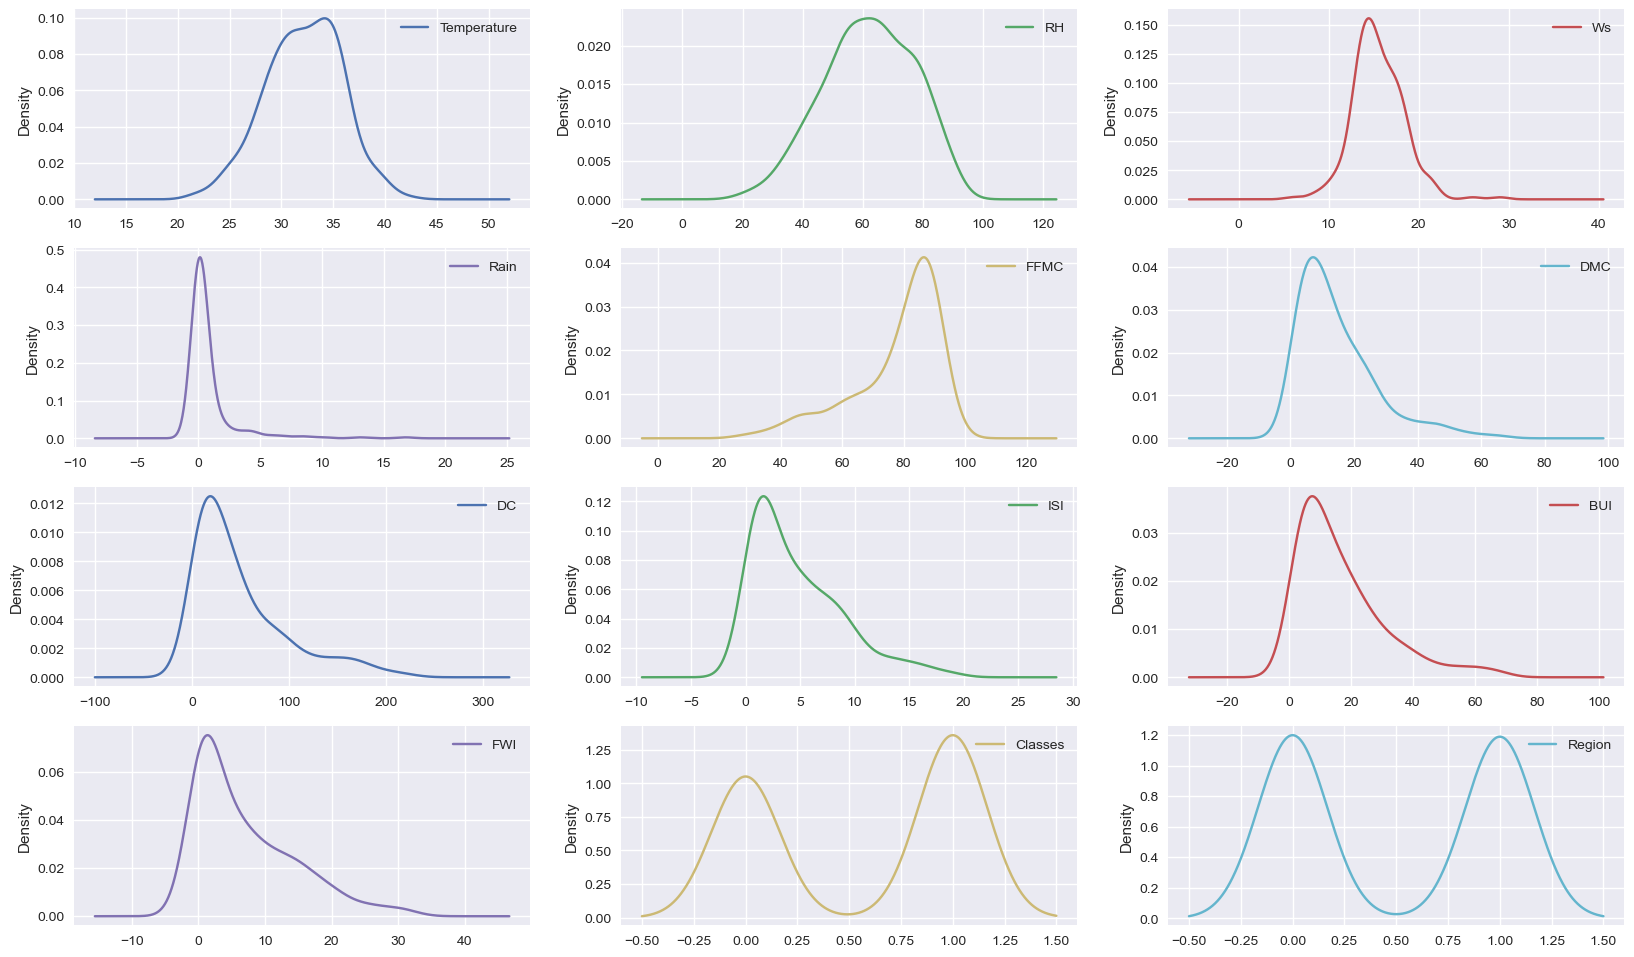

In [35]:
## Plot density plot for all features
plt.style.use('seaborn-v0_8')
df_copy.plot(kind='kde',subplots=True,sharex=False,layout=(5,3),figsize=(20,15))
plt.show()

In [36]:
## percentage for pie chart
percentage=df_copy['Classes'].value_counts(normalize=True)*100

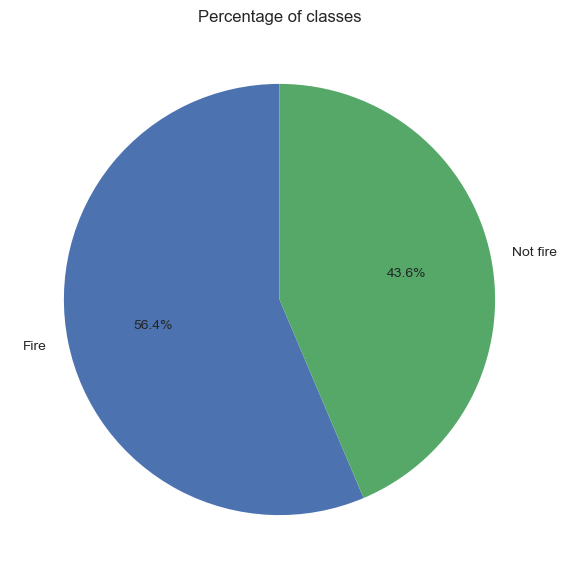

In [37]:
classlabels=["Fire","Not fire"]
plt.figure(figsize=(12,7))
plt.pie(percentage,labels=classlabels,autopct='%1.1f%%',shadow=False,startangle=90)
plt.title('Percentage of classes')
plt.show()

In [38]:
## Correlation
df_copy.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


<Axes: >

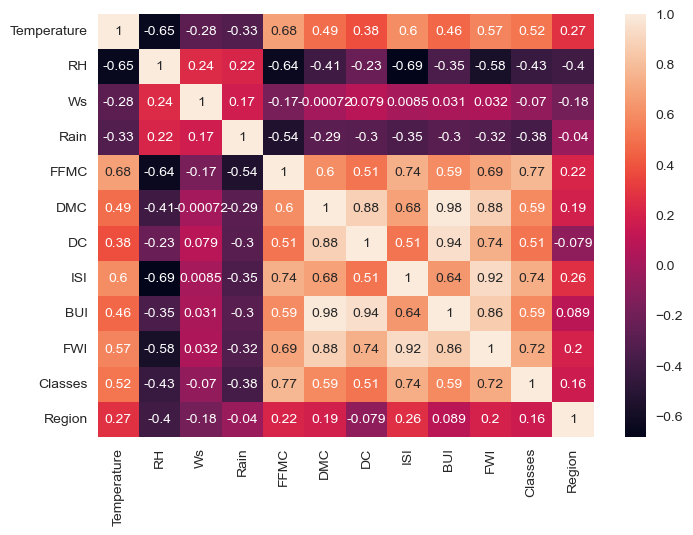

In [39]:
sns.heatmap(df_copy.corr(),annot=True)

<Axes: ylabel='FWI'>

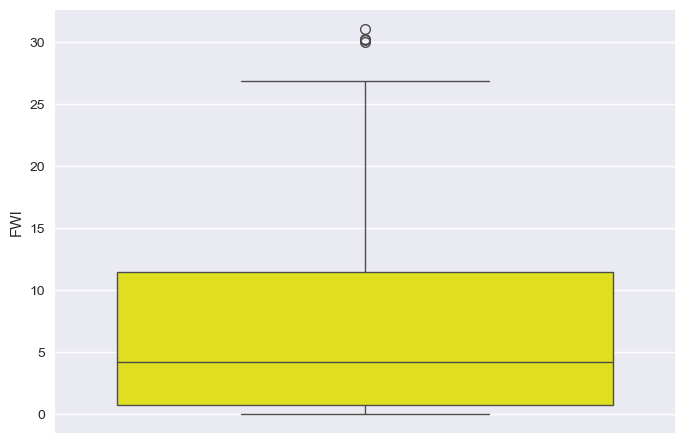

In [40]:
## Box Plots
sns.boxplot(df_copy['FWI'],color='yellow')

In [41]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [42]:
df['Classes']=np.where(df['Classes'].str.contains('not fire'),'not fire','fire')

Text(0.5, 1.0, 'Monthly fire analysis(Bejaia Region)')

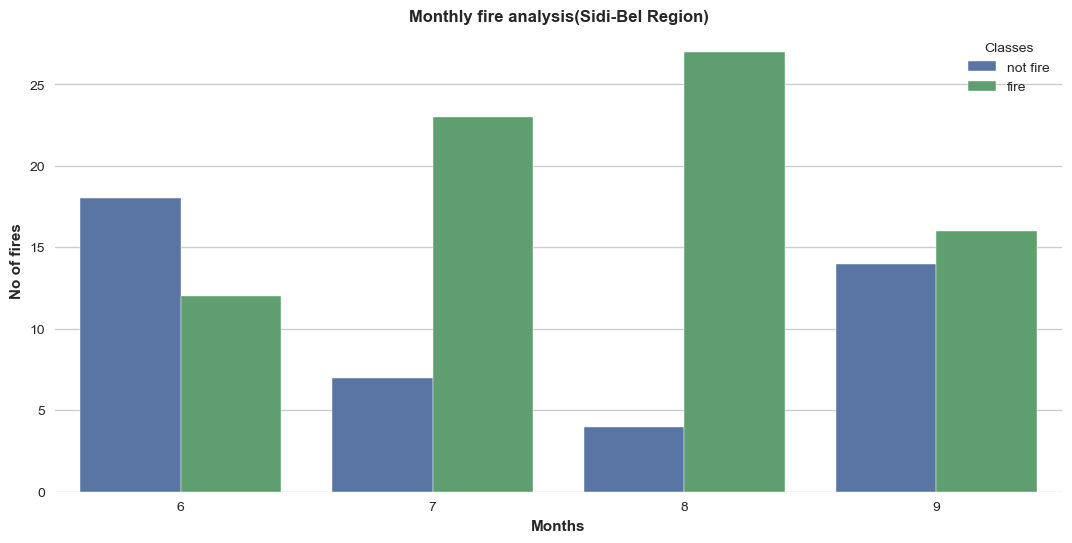

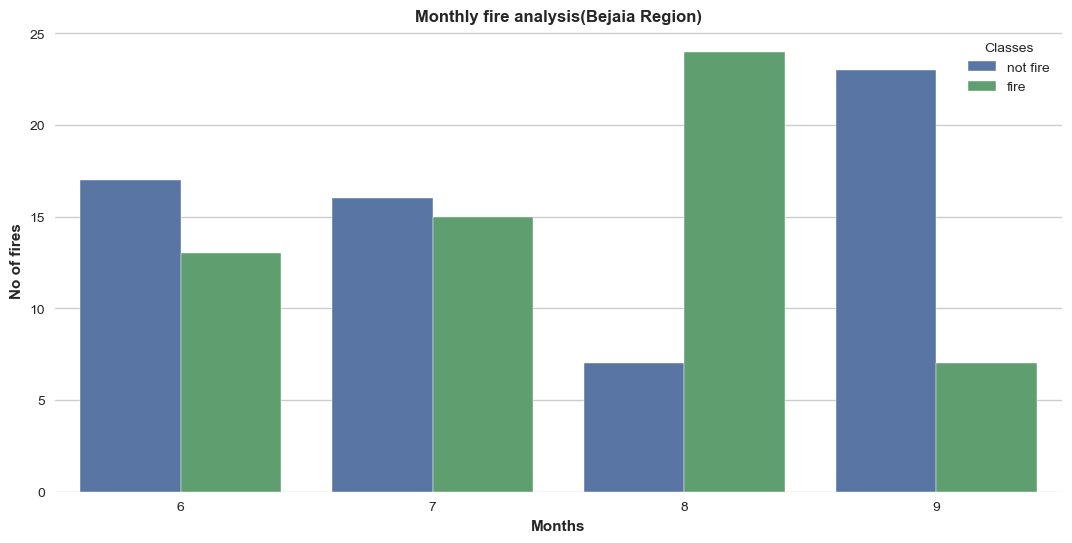

In [43]:
## Monthly fire analysis
sns.set_style('whitegrid')

dftemp1=df.loc[df['Region']==1]
plt.figure(figsize=(13,6))
sns.countplot(x='month',hue='Classes',data=dftemp1)
plt.ylabel("No of fires",weight='bold')
plt.xlabel("Months",weight='bold')
plt.title("Monthly fire analysis(Sidi-Bel Region)",weight='bold')
dftemp2=df.loc[df['Region']==0]
plt.figure(figsize=(13,6))
sns.countplot(x='month',hue='Classes',data=dftemp2)
plt.ylabel("No of fires",weight='bold')
plt.xlabel("Months",weight='bold')
plt.title("Monthly fire analysis(Bejaia Region)",weight='bold')

#### ***Observations from the above graphs***
1. **Peak fire activity occurs in August (month = 8) for both regions**, with fire counts significantly higher than "not fire", indicating strong seasonal impact.

2. **Sidi-Bel region shows a sharp increase in fires from June to August**, while "not fire" cases drop — suggesting higher fire intensity during peak summer.

3. **Bejaia region has relatively balanced fire vs not fire cases in June and July**, but shows a spike in fires in August and a sharp drop in September.

4. **September trends differ between regions**:
   - Sidi-Bel: fire and not fire counts are closer (moderate activity)
   - Bejaia: "not fire" dominates, indicating reduced fire incidents after peak season

#### ***Model training***

In [44]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [45]:
df.drop(columns=['day','month','year'],inplace=True)

In [46]:
df.head(2)

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0


In [47]:
df['Classes']=np.where(df['Classes'].str.contains("not fire"),0,1)

In [48]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [49]:
X=df.drop('FWI',axis=1)
y=df['FWI']

In [50]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [51]:
y.head()

0    0.5
1    0.4
2    0.1
3    0.0
4    0.5
Name: FWI, dtype: float64

In [52]:
## TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [53]:
X_train.shape,X_test.shape

((182, 11), (61, 11))

In [54]:
corr=X_train.corr()

<Axes: >

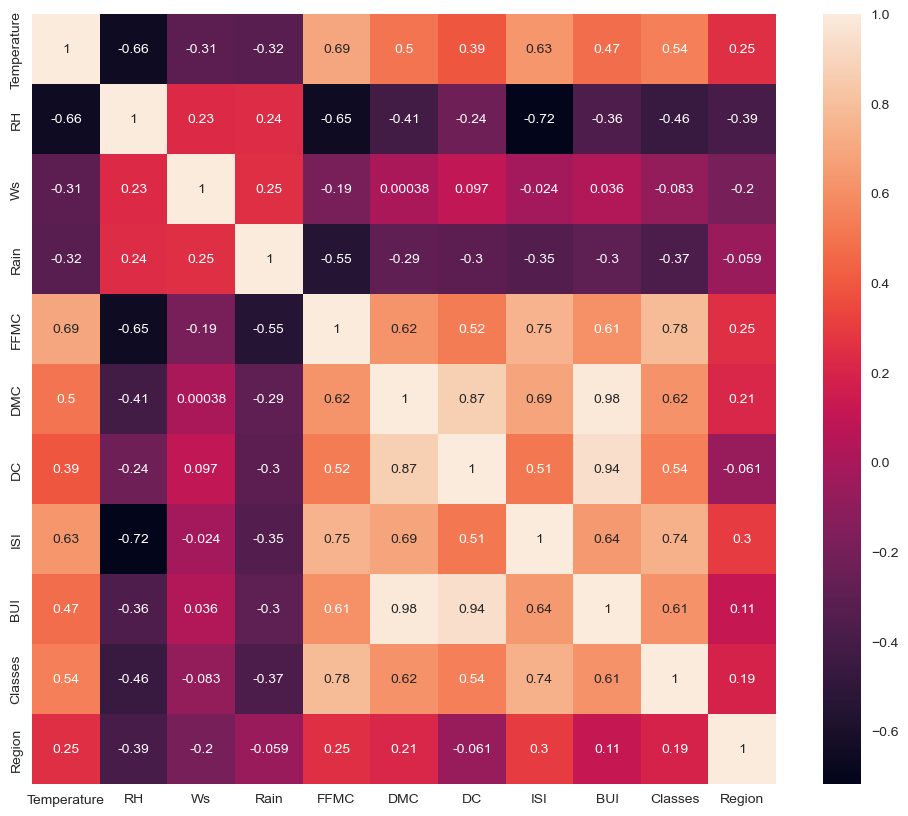

In [55]:
## Check for multicollinearity
plt.figure(figsize=(12,10))
sns.heatmap(corr,annot=True)


In [56]:
def correlation(dataset,threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr


In [57]:
corr_features=correlation(X_train,0.85)

In [58]:
## drop feature where correlation is more than 0.85
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)
X_train.shape,X_test.shape

((182, 9), (61, 9))

#### **Feature Scaling or Standardization**

In [59]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

#### **Box plots to understand effect of Standardization on the data**


Text(0.5, 1.0, 'X_train before Scaling')

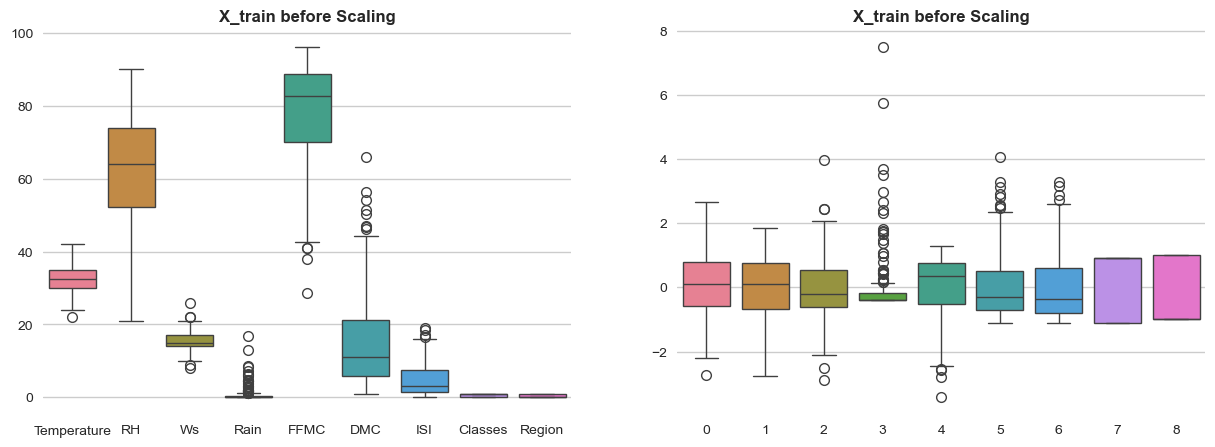

In [60]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title('X_train before Scaling', weight='bold')
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train before Scaling', weight='bold')


#### ***Linear Regression Model***

Mean Absolute Error :  0.5468236465249993
R2 score : 0.9847657384266951


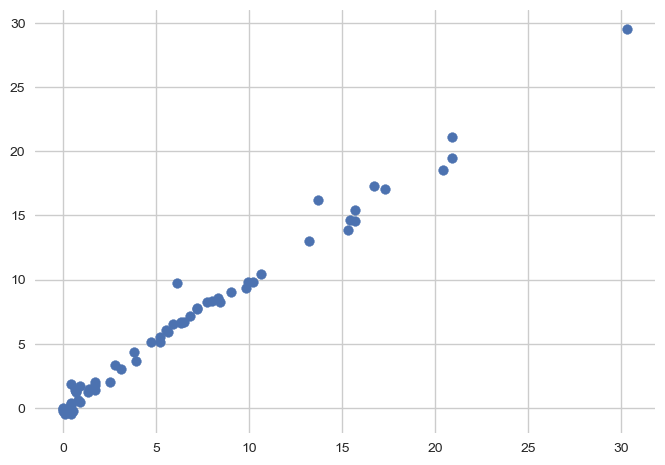

In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import *
linreg=LinearRegression()
linreg.fit(X_train_scaled,y_train)
y_pred=linreg.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean Absolute Error : ",mae)
print("R2 score :",score)

plt.scatter(y_test,y_pred)

#### ***Lasso Regresssion***

MAE: 0.7084773819658265
R2 Score: 0.9783246631008717


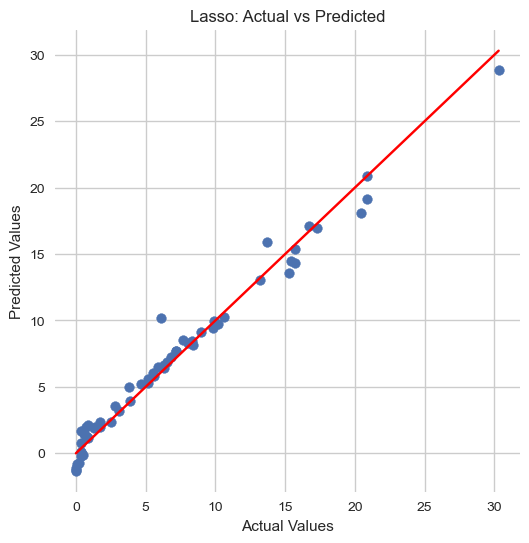

In [62]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Model
lasso = Lasso(alpha=0.1)   # alpha = regularization strength
lasso.fit(X_train_scaled, y_train)

# Prediction
y_pred_lasso = lasso.predict(X_test_scaled)

# Evaluation
mae = mean_absolute_error(y_test, y_pred_lasso)
r2 = r2_score(y_test, y_pred_lasso)

print("MAE:", mae)
print("R2 Score:", r2)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lasso)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Lasso: Actual vs Predicted")

plt.show()

In [63]:
y_test.mean()
## mae approx 10% of y_test.mean() -- good

np.float64(6.6754098360655725)

In [64]:
print("Train R2:", r2_score(y_train, lasso.predict(X_train_scaled)))
print("Test R2:", r2_score(y_test, y_pred_lasso))

Train R2: 0.9673808316219827
Test R2: 0.9783246631008717


#### ***Ridge regression Model***

In [65]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

# Model
ridge = Ridge(alpha=0.1)
ridge.fit(X_train_scaled, y_train)

# Prediction
y_pred_ridge = ridge.predict(X_test_scaled)

# Evaluation
print("Train R2:", r2_score(y_train, ridge.predict(X_train_scaled)))
print("Test R2:", r2_score(y_test, y_pred_ridge))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))

Train R2: 0.9699072540233197
Test R2: 0.9847238879049787
MAE: 0.5481365412366687


#### ***ElasticNET Model***

In [66]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score

# Model
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)  
# l1_ratio: 0 → Ridge, 1 → Lasso

elastic.fit(X_train_scaled, y_train)

# Prediction
y_pred_en = elastic.predict(X_test_scaled)

# Evaluation
print("Train R2:", r2_score(y_train, elastic.predict(X_train_scaled)))
print("Test R2:", r2_score(y_test, y_pred_en))
print("MAE:", mean_absolute_error(y_test, y_pred_en))

Train R2: 0.9654331525754394
Test R2: 0.9745920377156688
MAE: 0.8291276215817327


- Among Linear, Lasso, Ridge, and ElasticNet models, Ridge Regression 
performed the best with the highest R² score (~0.984) and lowest MAE (~0.548). 
- This indicates that all features contribute meaningfully to the prediction, 
and regularization without feature elimination is optimal. 
- ElasticNet and Lasso underperformed due to unnecessary feature shrinkage.

#### ***Cross Validation Lasso***

In [67]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV()
lassocv.fit(X_train_scaled,y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,None
,verbose,False
,n_jobs,None


In [68]:
alpha=lassocv.alpha_

In [69]:
lassocv.mse_path_

array([[53.64536329, 65.39074075, 54.89628985, 77.90299066, 39.38236846],
       [46.99139716, 59.81506814, 49.29840831, 75.6645852 , 35.31758355],
       [41.14908917, 53.9178721 , 42.49594889, 68.35708298, 31.76996123],
       [36.05788169, 48.41773965, 36.66879347, 61.92819453, 28.67296816],
       [31.62067285, 42.76466229, 31.68391904, 56.26841266, 24.93183295],
       [27.75285367, 37.81922812, 27.42599138, 51.28216115, 21.56888645],
       [24.3807738 , 33.49107651, 23.7950306 , 45.25481907, 18.66094162],
       [21.44052804, 29.70161639, 20.70460191, 39.90418045, 16.14837778],
       [18.876308  , 26.38208059, 18.07969934, 35.23429953, 13.97821475],
       [16.63960395, 23.47341883, 15.85530749, 31.15712074, 12.10483403],
       [14.68819307, 20.92329068, 13.97555108, 27.59649208, 10.48862803],
       [12.98525144, 18.68636627, 12.39173305, 24.48611006,  9.09521221],
       [11.49893734, 16.72312788, 11.06186319, 21.7677198 ,  7.89445038],
       [10.2013182 , 14.9991189 ,  9.9

Test R2: 0.9820946715928275
MAE: 0.6199701158263432


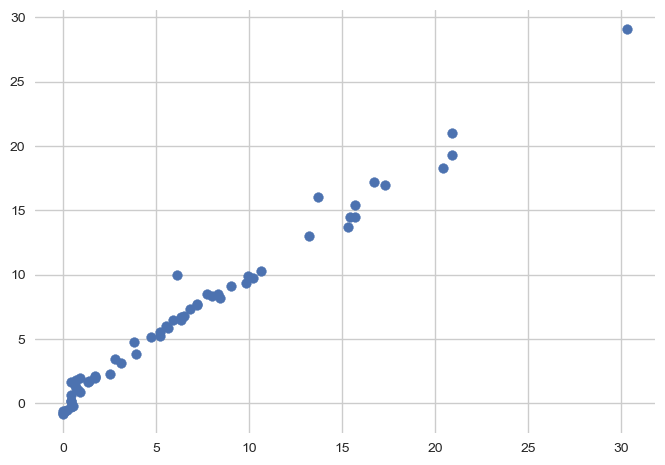

In [70]:
y_pred_lassocv=lassocv.predict(X_test_scaled)
print("Test R2:", r2_score(y_test, y_pred_lassocv))
print("MAE:", mean_absolute_error(y_test, y_pred_lassocv))
plt.scatter(y_test,y_pred_lassocv)


#### ***Cross Validation Ridge***

In [71]:
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)

,alphas,"(0.1, ...)"
,fit_intercept,True
,scoring,None
,cv,5
,gcv_mode,None
,store_cv_results,False
,alpha_per_target,False


Test R2: 0.9847238879049787
MAE: 0.5481365412366687


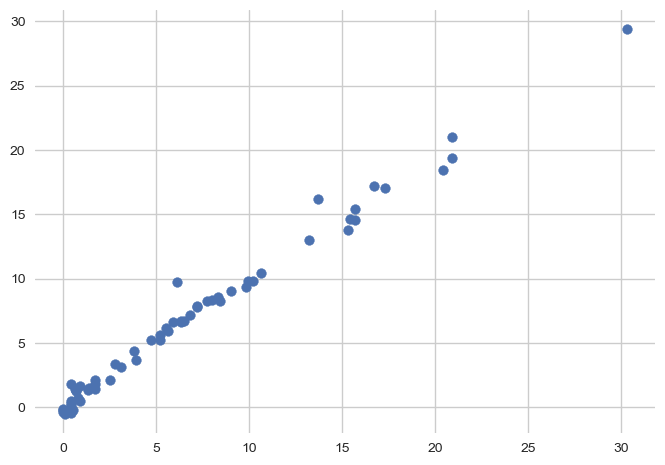

In [72]:
y_pred_ridgecv=ridgecv.predict(X_test_scaled)
plt.scatter(y_test,y_pred_ridgecv)
print("Test R2:", r2_score(y_test, y_pred_ridge))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))

In [73]:
ridgecv.alpha_

np.float64(1.0)

#### ***Cross Validation ElasticNET***

Best alpha: 0.04311146156383891
Best l1_ratio: 0.5
Train R2: 0.9688828442730821
Test R2: 0.9745920377156688
MAE: 0.8291276215817327


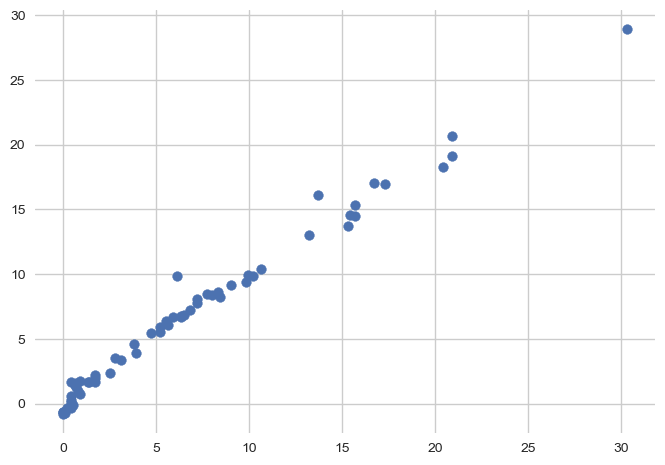

In [74]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, r2_score

# Model
elastic_cv = ElasticNetCV(cv=5)

# Train
elastic_cv.fit(X_train_scaled, y_train)

# Prediction
y_pred_encv = elastic_cv.predict(X_test_scaled)

# Evaluation
print("Best alpha:", elastic_cv.alpha_)
print("Best l1_ratio:", elastic_cv.l1_ratio_)
print("Train R2:", r2_score(y_train, elastic_cv.predict(X_train_scaled)))
print("Test R2:", r2_score(y_test, y_pred_en))
print("MAE:", mean_absolute_error(y_test, y_pred_en))
plt.scatter(y_test,y_pred_encv)
plt.show()

Pickle the machine learning models, preprocessing model standardscaler

In [75]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [76]:
ridge

,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [77]:
import pickle
with open('scaler.pkl','wb') as f:
    pickle.dump(scaler,f)  ## Pickling
with open('ridge.pkl','wb') as f:
    pickle.dump(ridge,f)  ## Pickling